# Employee Salary Prediction

# 1. Importing necessary libraries

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

# 2. Loading the Data

In [34]:
df = pd.read_csv(r"C:\Users\sahan\Downloads\employee_salary_prediction.csv")
df.head()

,years_experience,education_level,skill_score,certifications,salary
0,6,Masters,61,2,84335.511334
1,3,Bachelors,60,1,58370.973063
2,12,Bachelors,45,1,79844.807965
3,14,Masters,40,2,85823.798797
4,10,PhD,44,5,105660.618037


# 3. Basic Checks

In [35]:
df.shape

(500, 5)

In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   years_experience  500 non-null    int64  
 1   education_level   500 non-null    object 
 2   skill_score       500 non-null    int64  
 3   certifications    500 non-null    int64  
 4   salary            500 non-null    float64
dtypes: float64(1), int64(3), object(1)
memory usage: 19.7+ KB


In [37]:
df.isnull().sum()

years_experience    0
education_level     0
skill_score         0
certifications      0
salary              0
dtype: int64

# 4. Encoding Categorical Variables

In [39]:
encoders={}
for col in df.select_dtypes(include=['object','string']).columns:
    le= LabelEncoder()
    df[col]=le.fit_transform(df[col])
    encoders[col]=le

In [40]:
df.head()

,years_experience,education_level,skill_score,certifications,salary
0,6,1,61,2,84335.511334
1,3,0,60,1,58370.973063
2,12,0,45,1,79844.807965
3,14,1,40,2,85823.798797
4,10,2,44,5,105660.618037


# 5. Feature & target selection

In [9]:
X = df.drop("salary", axis=1)
y = df["salary"]

# 6. Train - Test split

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 7. Feature Scaling

In [41]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 8. Train Linear Regression Model

In [11]:
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


# 9. Predictions

In [12]:
y_pred = model.predict(X_test)

# 10. Model Evaluation

In [14]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)

MAE: 3550.796385674987
MSE: 19770912.595782302
RMSE: 4446.449436998278


# 10: Visualization

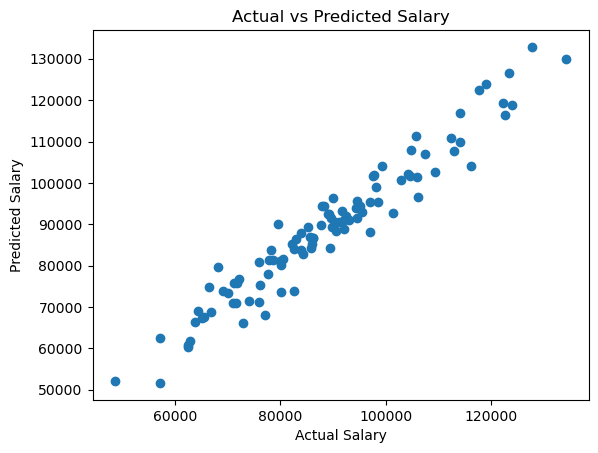

In [15]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.title("Actual vs Predicted Salary")
plt.show()

# 11: Model Interpretation

In [42]:
coefficients = pd.DataFrame(model.coef_, X.columns, columns=["Coefficient"])
coefficients

,Coefficient
years_experience,3004.776455
skill_score,488.173216
certifications,1984.507582
education_level_Masters,9880.175121
education_level_PhD,19338.159694


# 12. Check Model Accuracy (R² Score)

In [45]:
from sklearn.metrics import r2_score
"R2 Score:", r2_score(y_test, y_pred)

('R2 Score:', 0.9357502214100821)